> ## VodaPulse Exploratory Data Analysis

## 1) Data Inspection

In [0]:
!pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [0]:
df = pd.read_csv("/Workspace/Users/hlophetshepiso4@gmail.com/Project VodaPulse (built for the proxy network VodaPulse Connect)/vodapulse_raw_dataset.csv")

In [0]:
display(df)

Date,Subscriber_ID,Customer_Age,Province,Area_Type,Contract_Type,Device_Type,Payment_Method,Network_Experience,Support_Ticket_Type,Load_Shedding_Impact,App_Engagement,Data_Usage_GB,ARPU_ZAR
2026-06-13,VP_10000,56,Gauteng,Rural,Enterprise Hybrid,4G Smartphone,Debit Order,Excellent,null,Severe (Stage 4+),Moderate,3.6,136.68
2026-01-29,VP_10001,69,Gauteng,Rural,Prepaid,4G Smartphone,Voucher Top-Up,Good,SIM Swap / Technical,Severe (Stage 4+),High Active,8.1,204.79
2026-01-07,VP_10002,46,KwaZulu-Natal,Suburban,Prepaid,5G Smartphone,Credit Card,Good,Billing Query,Moderate (Stage 1-3),Moderate,29.5,528.71
2026-03-12,VP_10003,32,Limpopo,Urban,Prepaid,4G Smartphone,Debit Order,Fair,null,Severe (Stage 4+),Low / Inactive,34.2,599.86
2026-03-04,VP_10004,60,Gauteng,Urban,Prepaid,5G Smartphone,Voucher Top-Up,Good,null,Moderate (Stage 1-3),Moderate,24.4,451.52
2026-02-27,VP_10005,25,Western Cape,Urban,Prepaid,4G Smartphone,Voucher Top-Up,Excellent,null,Moderate (Stage 1-3),Low / Inactive,6.1,174.52
2026-02-05,VP_10006,38,Gauteng,Suburban,Postpaid Contract,4G Smartphone,Voucher Top-Up,Fair,null,Moderate (Stage 1-3),Moderate,10.4,239.61
2026-01-27,VP_10007,56,Gauteng,Urban,Enterprise Hybrid,5G Smartphone,Debit Order,Good,Network Coverage,Severe (Stage 4+),High Active,16.8,336.48
2026-06-23,VP_10008,36,Eastern Cape,Rural,Prepaid,4G Smartphone,Credit Card,Fair,null,Severe (Stage 4+),High Active,33.0,581.69
2026-05-20,VP_10009,40,Western Cape,Rural,Postpaid Contract,5G Smartphone,Voucher Top-Up,Fair,null,Moderate (Stage 1-3),Moderate,21.5,407.62


In [0]:
# Columns of the dataset
df.columns

Index(['Date', 'Subscriber_ID', 'Customer_Age', 'Province', 'Area_Type',
       'Contract_Type', 'Device_Type', 'Payment_Method', 'Network_Experience',
       'Support_Ticket_Type', 'Load_Shedding_Impact', 'App_Engagement',
       'Data_Usage_GB', 'ARPU_ZAR'],
      dtype='object')

In [0]:
# Dataset shape (numober of rows, number of columns)
print(df.shape)

(5000, 14)


There are 5000 rows and 14 columns in the dataset

In [0]:
# Getting the first 5 rows of the dataset
df.head(5)

,Date,Subscriber_ID,Customer_Age,Province,Area_Type,Contract_Type,Device_Type,Payment_Method,Network_Experience,Support_Ticket_Type,Load_Shedding_Impact,App_Engagement,Data_Usage_GB,ARPU_ZAR
0,2026-06-13,VP_10000,56,Gauteng,Rural,Enterprise Hybrid,4G Smartphone,Debit Order,Excellent,NaN,Severe (Stage 4+),Moderate,3.6,136.68
1,2026-01-29,VP_10001,69,Gauteng,Rural,Prepaid,4G Smartphone,Voucher Top-Up,Good,SIM Swap / Technical,Severe (Stage 4+),High Active,8.1,204.79
2,2026-01-07,VP_10002,46,KwaZulu-Natal,Suburban,Prepaid,5G Smartphone,Credit Card,Good,Billing Query,Moderate (Stage 1-3),Moderate,29.5,528.71
3,2026-03-12,VP_10003,32,Limpopo,Urban,Prepaid,4G Smartphone,Debit Order,Fair,NaN,Severe (Stage 4+),Low / Inactive,34.2,599.86
4,2026-03-04,VP_10004,60,Gauteng,Urban,Prepaid,5G Smartphone,Voucher Top-Up,Good,NaN,Moderate (Stage 1-3),Moderate,24.4,451.52


In [0]:
# Getting the Data Types & Non-Null Counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  5000 non-null   object 
 1   Subscriber_ID         5000 non-null   object 
 2   Customer_Age          5000 non-null   int64  
 3   Province              5000 non-null   object 
 4   Area_Type             5000 non-null   object 
 5   Contract_Type         5000 non-null   object 
 6   Device_Type           5000 non-null   object 
 7   Payment_Method        5000 non-null   object 
 8   Network_Experience    5000 non-null   object 
 9   Support_Ticket_Type   1736 non-null   object 
 10  Load_Shedding_Impact  5000 non-null   object 
 11  App_Engagement        5000 non-null   object 
 12  Data_Usage_GB         5000 non-null   float64
 13  ARPU_ZAR              5000 non-null   float64
dtypes: float64(2), int64(1), object(11)
memory usage: 547.0+ KB


In [0]:
# Counting the Missing/Null Values
df.isnull().sum()

Date                       0
Subscriber_ID              0
Customer_Age               0
Province                   0
Area_Type                  0
Contract_Type              0
Device_Type                0
Payment_Method             0
Network_Experience         0
Support_Ticket_Type     3264
Load_Shedding_Impact       0
App_Engagement             0
Data_Usage_GB              0
ARPU_ZAR                   0
dtype: int64

There are 3264 missing values in the Support_Ticket_Type column

Handling Null Values:

In [0]:
# Handling the missing values by replacing them with No Ticket
df["Support_Ticket_Type"] = (
    df["Support_Ticket_Type"]
    .fillna("No_Ticket")
)

In [0]:
# Checking for any duplicated rows
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [0]:
# Checking if there are duplicate subscribers (Number of Unique Subscribers)
print("Number of Unique Subscribers:", df["Subscriber_ID"].nunique())

Number of Unique Subscribers: 5000


## 2) Exploratory Data Analysis (EDA)

### 2.1 Clean the Date

In [0]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Lowest Date:", df["Date"].min())
print("Highest Date:",df["Date"].max())

Lowest Date: 2026-01-01 00:00:00
Highest Date: 2026-06-30 00:00:00


In [0]:
# Creating useful time variables
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Month_Period"] = df["Date"].dt.to_period("M")

In [0]:
df.head(5)

,Date,Subscriber_ID,Customer_Age,Province,Area_Type,Contract_Type,Device_Type,Payment_Method,Network_Experience,Support_Ticket_Type,Load_Shedding_Impact,App_Engagement,Data_Usage_GB,ARPU_ZAR,Year,Month,Month_Name,Month_Period
0,2026-06-13,VP_10000,56,Gauteng,Rural,Enterprise Hybrid,4G Smartphone,Debit Order,Excellent,No_Ticket,Severe (Stage 4+),Moderate,3.6,136.68,2026,6,June,2026-06
1,2026-01-29,VP_10001,69,Gauteng,Rural,Prepaid,4G Smartphone,Voucher Top-Up,Good,SIM Swap / Technical,Severe (Stage 4+),High Active,8.1,204.79,2026,1,January,2026-01
2,2026-01-07,VP_10002,46,KwaZulu-Natal,Suburban,Prepaid,5G Smartphone,Credit Card,Good,Billing Query,Moderate (Stage 1-3),Moderate,29.5,528.71,2026,1,January,2026-01
3,2026-03-12,VP_10003,32,Limpopo,Urban,Prepaid,4G Smartphone,Debit Order,Fair,No_Ticket,Severe (Stage 4+),Low / Inactive,34.2,599.86,2026,3,March,2026-03
4,2026-03-04,VP_10004,60,Gauteng,Urban,Prepaid,5G Smartphone,Voucher Top-Up,Good,No_Ticket,Moderate (Stage 1-3),Moderate,24.4,451.52,2026,3,March,2026-03


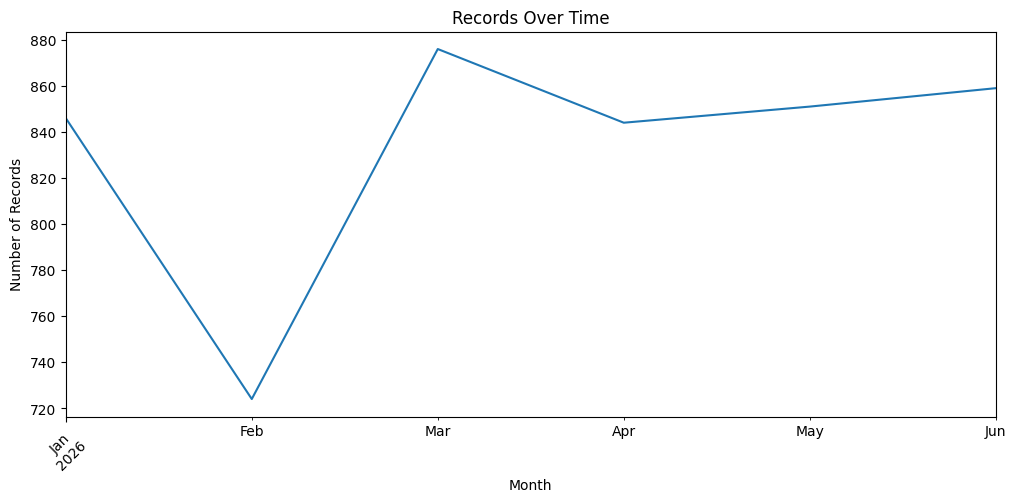

In [0]:
# Looking at the number of records over time
monthly_counts = df.groupby("Month_Period").size()

monthly_counts.plot(figsize=(12,5))
plt.title("Records Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

### 2.2 Univariate Analysis

In [0]:
# Summary Statistics for Numerical Variables
numeric_cols = [
    "Customer_Age",
    "Data_Usage_GB",
    "ARPU_ZAR"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,5000.0,46.148600,16.325753,18.0,32.00,46.00,60.00,74.00
Data_Usage_GB,5000.0,20.092200,14.340852,0.1,9.50,16.60,27.30,105.60
ARPU_ZAR,5000.0,386.311896,217.071550,83.7,225.98,333.45,495.41,1680.61


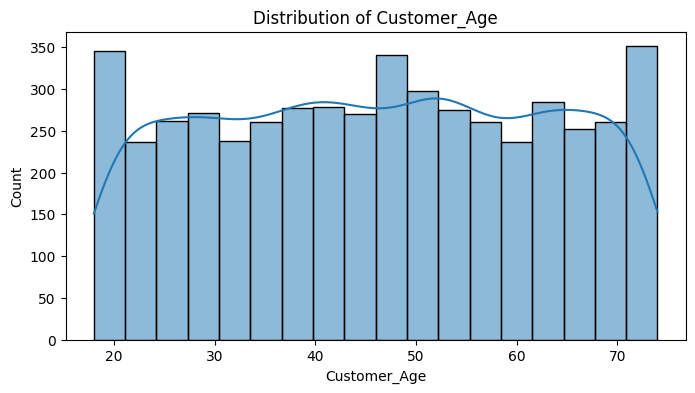

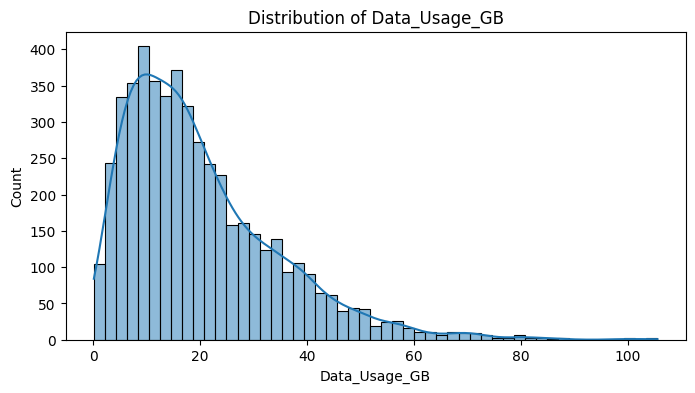

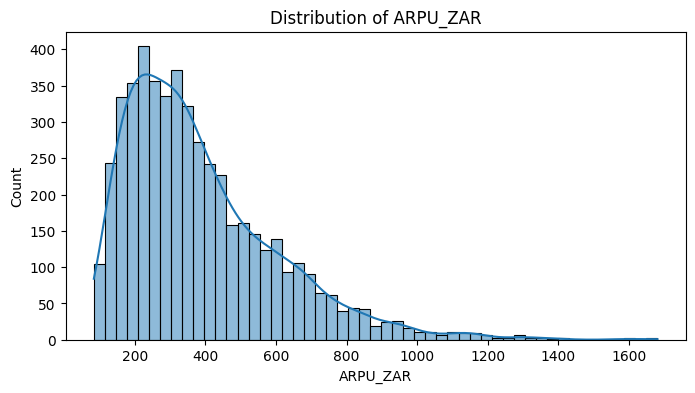

In [0]:
# Visualizing distributions
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()

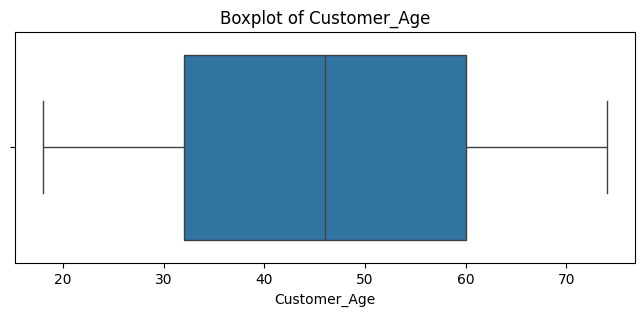

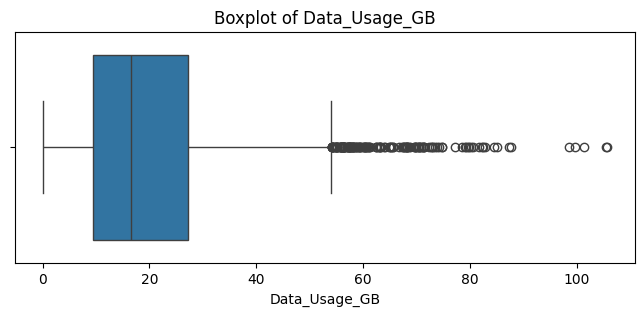

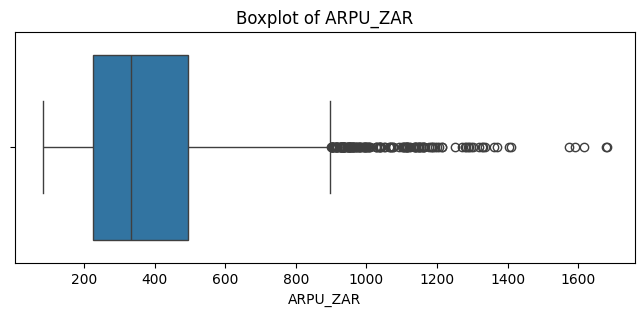

In [0]:
# Boxplot visualization for outliers
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### 2.3 Categorical Columns Analysis

In [0]:
# Get the frequency of every categorical variable
categorical_cols = [
    "Province",
    "Area_Type",
    "Contract_Type",
    "Device_Type",
    "Payment_Method",
    "Network_Experience",
    "Support_Ticket_Type",
    "Load_Shedding_Impact",
    "App_Engagement"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== Province =====
Province
Gauteng          1789
KwaZulu-Natal    1116
Western Cape      891
Eastern Cape      623
Limpopo           581
Name: count, dtype: int64

===== Area_Type =====
Area_Type
Urban       2782
Suburban    1476
Rural        742
Name: count, dtype: int64

===== Contract_Type =====
Contract_Type
Prepaid              3005
Postpaid Contract    1490
Enterprise Hybrid     505
Name: count, dtype: int64

===== Device_Type =====
Device_Type
4G Smartphone           2291
5G Smartphone           1903
LTE Router/MiFi          526
Legacy Feature Phone     280
Name: count, dtype: int64

===== Payment_Method =====
Payment_Method
Voucher Top-Up      2054
Debit Order         1752
Mobile App / EFT     714
Credit Card          480
Name: count, dtype: int64

===== Network_Experience =====
Network_Experience
Excellent                2057
Good                     1717
Fair                      736
Poor / Frequent Drops     490
Name: count, dtype: int64

===== Support_Ticket_Type =====


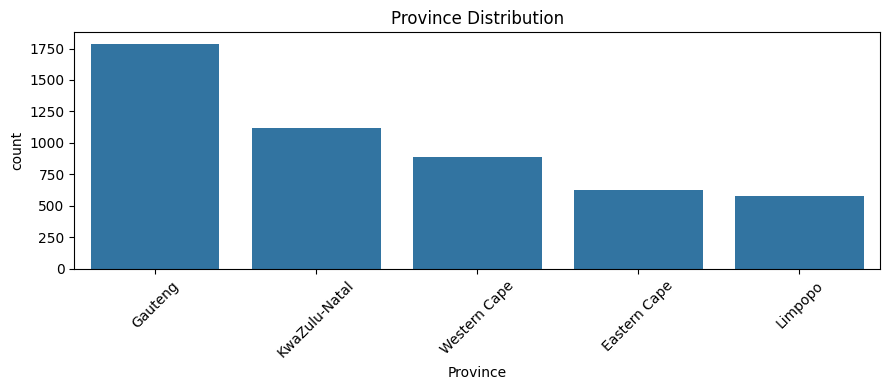

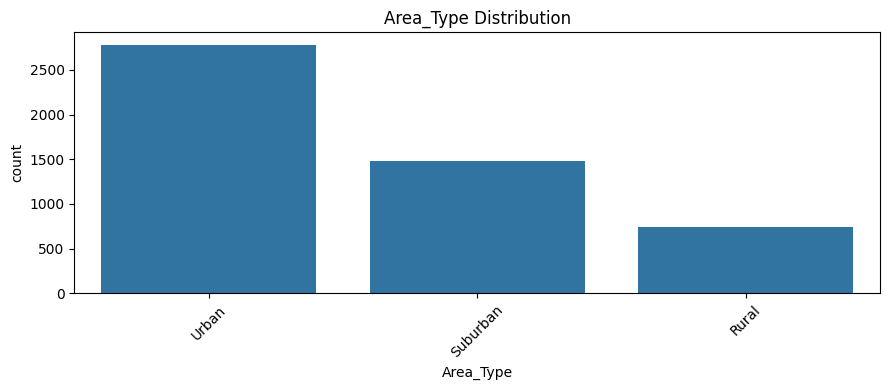

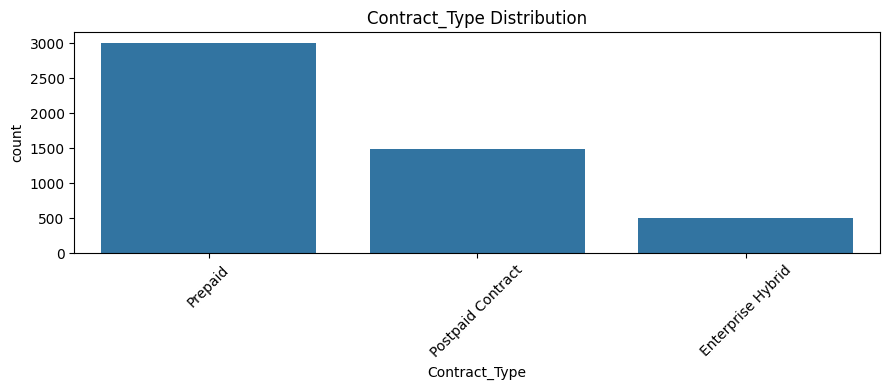

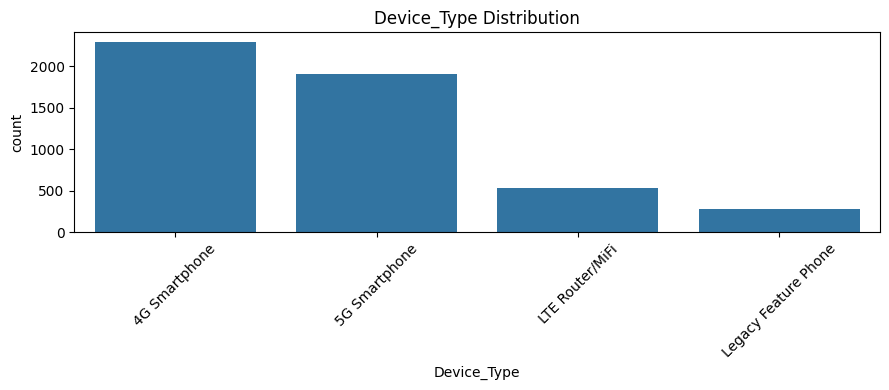

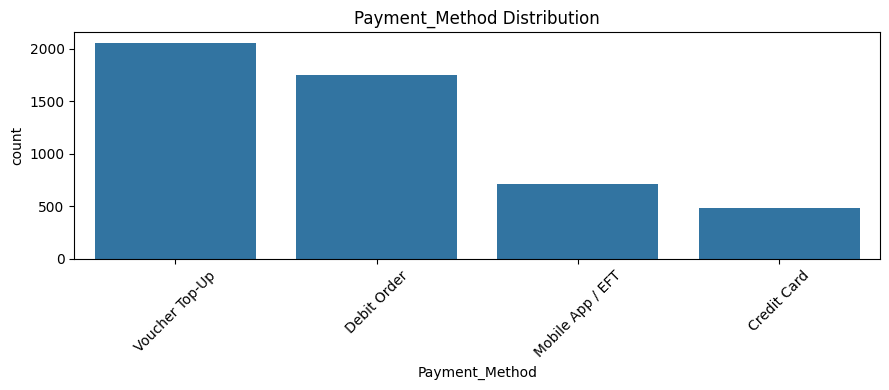

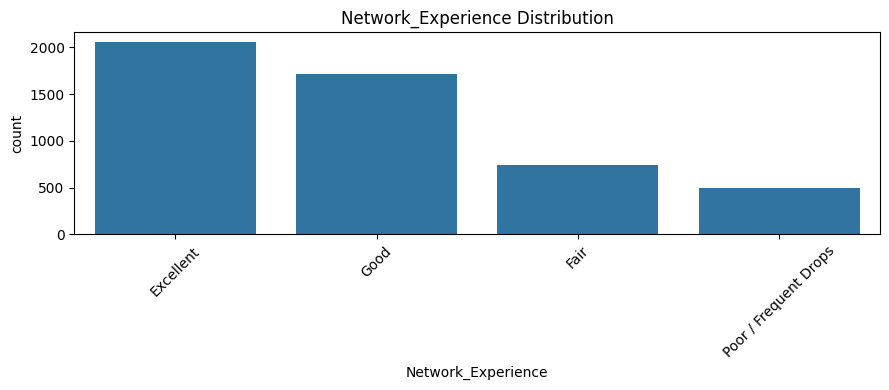

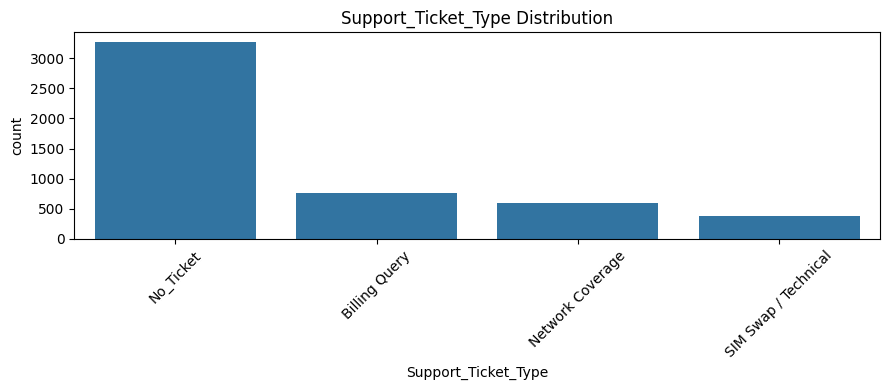

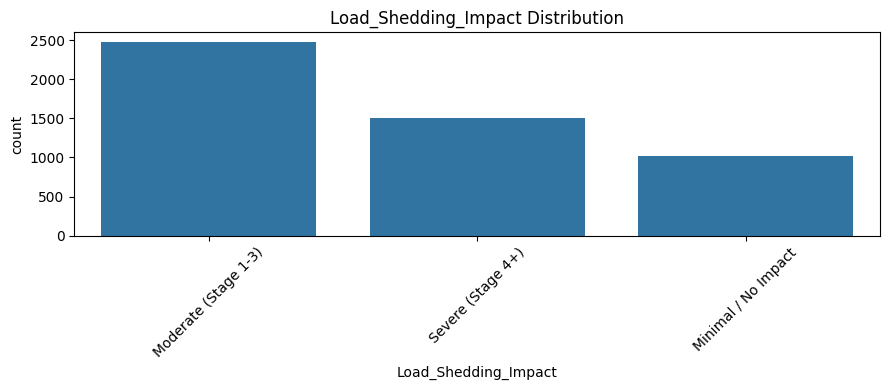

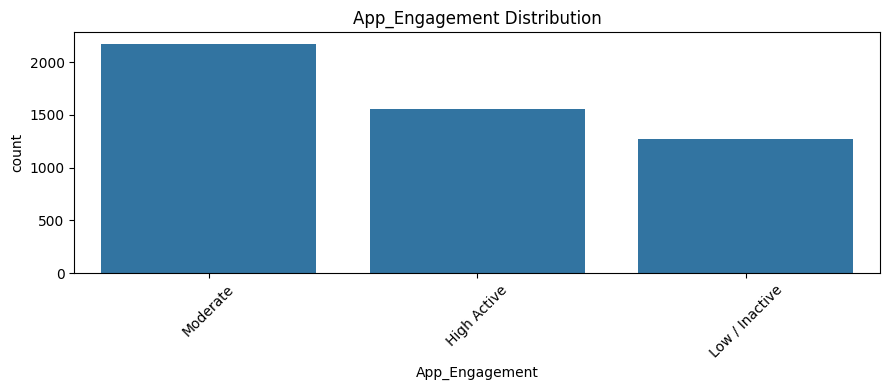

In [0]:
# Visualizing the number of different categories in the categorical columns
for col in categorical_cols:
    plt.figure(figsize=(9,4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 2.4 Province Analysis

In [0]:
province_summary = (
    df.groupby("Province")
      .agg(
          Customers=("Subscriber_ID", "nunique"),
          Avg_ARPU=("ARPU_ZAR", "mean"),
          Avg_Data_Usage=("Data_Usage_GB", "mean"),
          Avg_Age=("Customer_Age", "mean")
      )
      .sort_values("Customers", ascending=False)
).reset_index()

display(province_summary.round(2))

Province,Customers,Avg_ARPU,Avg_Data_Usage,Avg_Age
Gauteng,1789,385.05,20.01,45.94
KwaZulu-Natal,1116,381.86,19.8,46.38
Western Cape,891,390.82,20.39,45.2
Eastern Cape,623,386.7,20.12,46.82
Limpopo,581,391.42,20.43,47.08


### 2.5 Customer Age Analysis

In [0]:
# Creating sensible age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = [
    "Under 18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=bins,
    labels=labels,
    right=False
)

In [0]:
# Summary for Age Groups
age_summary = df.groupby("Age_Group", observed=True).agg(
    Customers=("Subscriber_ID", "nunique"),
    Total_ARPU=("ARPU_ZAR", "sum"),
    Avg_ARPU=("ARPU_ZAR", "mean"),
    Avg_Data_Usage=("Data_Usage_GB", "mean")
).reset_index()

display(age_summary.round(2))

Age_Group,Customers,Total_ARPU,Avg_ARPU,Avg_Data_Usage
18-24,582,216755.64,372.43,19.18
25-34,866,330391.93,381.51,19.78
35-44,890,357672.66,401.88,21.12
45-54,932,358522.57,384.68,19.98
55-64,866,338179.68,390.51,20.37
65+,864,330037.0,381.99,19.81


### 2.6 ARPU Analysis

In [0]:
# Looking at average & median ARPU:
print("Average ARPU:", df["ARPU_ZAR"].mean())
print("Median ARPU:", df["ARPU_ZAR"].median())

Average ARPU: 386.311896
Median ARPU: 333.45


In [0]:
# Compare ARPU across customer characteristics:
group_cols = [
    "Province",
    "Area_Type",
    "Contract_Type",
    "Device_Type",
    "Payment_Method",
    "Network_Experience",
    "Load_Shedding_Impact",
    "App_Engagement"
]

for col in group_cols:
    summary = (
        df.groupby(col)["ARPU_ZAR"]
        .agg(["count", "mean", "median", "sum"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

    print(f"\n===== ARPU by {col} =====")
    display(summary.round(2))


===== ARPU by Province =====


Province,count,mean,median,sum
Limpopo,581,391.42,341.02,227414.55
Western Cape,891,390.82,341.02,348217.38
Eastern Cape,623,386.7,337.99,240916.92
Gauteng,1789,385.05,330.42,688854.44
KwaZulu-Natal,1116,381.86,330.42,426156.19



===== ARPU by Area_Type =====


Area_Type,count,mean,median,sum
Suburban,1476,394.66,342.53,582511.58
Rural,742,386.67,330.42,286908.13
Urban,2782,381.79,331.94,1062139.77



===== ARPU by Contract_Type =====


...

Network_Experience,count,mean,median,sum
Fair,736,389.36,327.4,286566.51
Excellent,2057,387.35,336.48,796779.94
Poor / Frequent Drops,490,384.53,327.4,188421.43
Good,1717,384.27,337.99,659791.6



===== ARPU by Load_Shedding_Impact =====


Load_Shedding_Impact,count,mean,median,sum
Severe (Stage 4+),1505,387.49,339.51,583175.7
Moderate (Stage 1-3),2477,386.92,336.48,958402.31
Minimal / No Impact,1018,383.09,324.37,389981.47



===== ARPU by App_Engagement =====


App_Engagement,count,mean,median,sum
Low / Inactive,1272,398.23,339.51,506542.32
Moderate,2173,386.64,336.48,840158.78
High Active,1555,376.11,325.88,584858.38


### 2.7 Data Usage Analysis

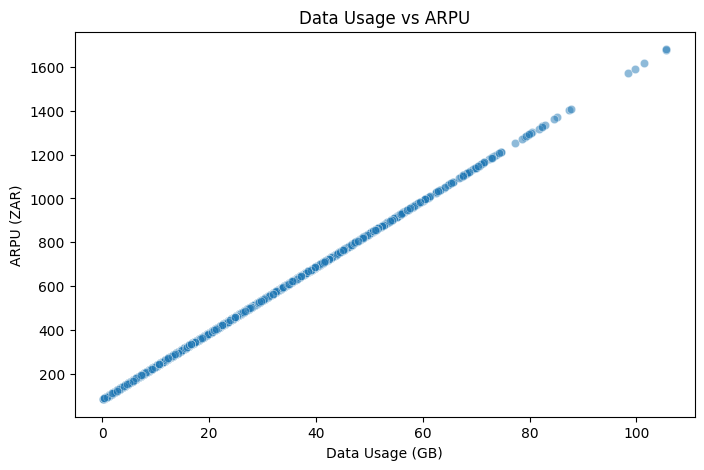

In [0]:
# Check the relationship between data usage and ARPU:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Data_Usage_GB",
    y="ARPU_ZAR",
    alpha=0.5
)

plt.title("Data Usage vs ARPU")
plt.xlabel("Data Usage (GB)")
plt.ylabel("ARPU (ZAR)")
plt.show()

In [0]:
# Calculate correlation:
df[["Customer_Age", "Data_Usage_GB", "ARPU_ZAR"]].corr()

,Customer_Age,Data_Usage_GB,ARPU_ZAR
Customer_Age,1.000000,0.009832,0.009832
Data_Usage_GB,0.009832,1.000000,1.000000
ARPU_ZAR,0.009832,1.000000,1.000000


In [0]:
# Examining usage by contract:
df.groupby("Contract_Type").agg(
    Avg_Data_Usage=("Data_Usage_GB", "mean"),
    Median_Data_Usage=("Data_Usage_GB", "median"),
    Avg_ARPU=("ARPU_ZAR", "mean"),
    Customers=("Subscriber_ID", "nunique")
).sort_values("Avg_Data_Usage", ascending=False)

,Avg_Data_Usage,Median_Data_Usage,Avg_ARPU,Customers
Contract_Type,,,,
Enterprise Hybrid,20.482178,16.70,392.214891,505
Prepaid,20.129118,16.70,386.870742,3005
Postpaid Contract,19.885570,16.45,383.184148,1490


### 2.8 Network Experience Analysis

In [0]:
df["Network_Experience"].value_counts()

Network_Experience
Excellent                2057
Good                     1717
Fair                      736
Poor / Frequent Drops     490
Name: count, dtype: int64

In [0]:
network_arpu = (
    df.groupby("Network_Experience")
      .agg(
          Customers=("Subscriber_ID", "nunique"),
          Avg_ARPU=("ARPU_ZAR", "mean"),
          Avg_Data_Usage=("Data_Usage_GB", "mean")
      )
).reset_index()

display(network_arpu.round(2))

Network_Experience,Customers,Avg_ARPU,Avg_Data_Usage
Excellent,2057,387.35,20.16
Fair,736,389.36,20.29
Good,1717,384.27,19.96
Poor / Frequent Drops,490,384.53,19.97


In [0]:
# Analysing support tickets & network experience
pd.crosstab(
    df["Network_Experience"],
    df["Support_Ticket_Type"],
    normalize="index"
) * 100

Support_Ticket_Type,Billing Query,Network Coverage,No_Ticket,SIM Swap / Technical
Network_Experience,,,,
Excellent,16.285853,11.861935,63.782207,8.070005
Fair,15.896739,12.500000,64.809783,6.793478
Good,14.443797,11.124054,66.860804,7.571345
Poor / Frequent Drops,12.448980,14.489796,66.734694,6.326531


### 2.9 Load Shedding Analysis

In [0]:
load_summary = df.groupby("Load_Shedding_Impact").agg(
    Customers=("Subscriber_ID", "nunique"),
    Avg_ARPU=("ARPU_ZAR", "mean"),
    Avg_Data_Usage=("Data_Usage_GB", "mean")
).reset_index()

display(load_summary.round(2))

Load_Shedding_Impact,Customers,Avg_ARPU,Avg_Data_Usage
Minimal / No Impact,1018,383.09,19.88
Moderate (Stage 1-3),2477,386.92,20.13
Severe (Stage 4+),1505,387.49,20.17


### 2.10 App Enagement Analysis

Looking whether more engaged customers differ in usage and ARPU

In [0]:
engagement_summary = df.groupby("App_Engagement").agg(
    Customers=("Subscriber_ID", "nunique"),
    Avg_ARPU=("ARPU_ZAR", "mean"),
    Avg_Data_Usage=("Data_Usage_GB", "mean")
).sort_values("Avg_ARPU", ascending=False).reset_index()

display(engagement_summary.round(2))

App_Engagement,Customers,Avg_ARPU,Avg_Data_Usage
Low / Inactive,1272,398.23,20.88
Moderate,2173,386.64,20.11
High Active,1555,376.11,19.42


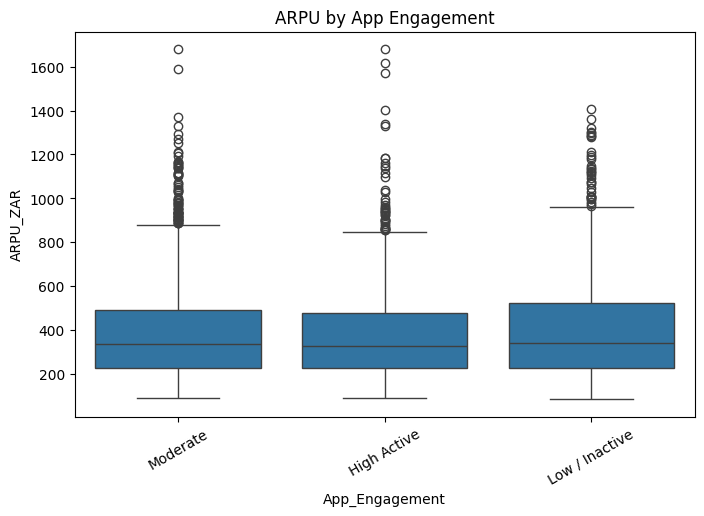

In [0]:
# Boxplot to check for outliers in app engagement 
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="App_Engagement",
    y="ARPU_ZAR"
)
plt.title("ARPU by App Engagement")
plt.xticks(rotation=30)
plt.show()

### 2.11 Contract Type Analysis

In [0]:
contract_summary = df.groupby("Contract_Type").agg(
    Customers=("Subscriber_ID", "nunique"),
    Total_ARPU=("ARPU_ZAR", "sum"),
    Avg_ARPU=("ARPU_ZAR", "mean"),
    Median_ARPU=("ARPU_ZAR", "median"),
    Avg_Data_Usage=("Data_Usage_GB", "mean"),
    Avg_Age=("Customer_Age", "mean")
).reset_index()

display(contract_summary.round(2))

Contract_Type,Customers,Total_ARPU,Avg_ARPU,Median_ARPU,Avg_Data_Usage,Avg_Age
Enterprise Hybrid,505,198068.52,392.21,334.97,20.48,45.53
Postpaid Contract,1490,570944.38,383.18,331.18,19.89,46.47
Prepaid,3005,1162546.58,386.87,334.97,20.13,46.1


In [0]:
display(df)

Date,Subscriber_ID,Customer_Age,Province,Area_Type,Contract_Type,Device_Type,Payment_Method,Network_Experience,Support_Ticket_Type,Load_Shedding_Impact,App_Engagement,Data_Usage_GB,ARPU_ZAR,Year,Month,Month_Name,Month_Period,Age_Group
2026-06-13T00:00:00.000Z,VP_10000,56,Gauteng,Rural,Enterprise Hybrid,4G Smartphone,Debit Order,Excellent,No_Ticket,Severe (Stage 4+),Moderate,3.6,136.68,2026,6,June,677,55-64
2026-01-29T00:00:00.000Z,VP_10001,69,Gauteng,Rural,Prepaid,4G Smartphone,Voucher Top-Up,Good,SIM Swap / Technical,Severe (Stage 4+),High Active,8.1,204.79,2026,1,January,672,65+
2026-01-07T00:00:00.000Z,VP_10002,46,KwaZulu-Natal,Suburban,Prepaid,5G Smartphone,Credit Card,Good,Billing Query,Moderate (Stage 1-3),Moderate,29.5,528.71,2026,1,January,672,45-54
2026-03-12T00:00:00.000Z,VP_10003,32,Limpopo,Urban,Prepaid,4G Smartphone,Debit Order,Fair,No_Ticket,Severe (Stage 4+),Low / Inactive,34.2,599.86,2026,3,March,674,25-34
2026-03-04T00:00:00.000Z,VP_10004,60,Gauteng,Urban,Prepaid,5G Smartphone,Voucher Top-Up,Good,No_Ticket,Moderate (Stage 1-3),Moderate,24.4,451.52,2026,3,March,674,55-64
2026-02-27T00:00:00.000Z,VP_10005,25,Western Cape,Urban,Prepaid,4G Smartphone,Voucher Top-Up,Excellent,No_Ticket,Moderate (Stage 1-3),Low / Inactive,6.1,174.52,2026,2,February,673,25-34
2026-02-05T00:00:00.000Z,VP_10006,38,Gauteng,Suburban,Postpaid Contract,4G Smartphone,Voucher Top-Up,Fair,No_Ticket,Moderate (Stage 1-3),Moderate,10.4,239.61,2026,2,February,673,35-44
2026-01-27T00:00:00.000Z,VP_10007,56,Gauteng,Urban,Enterprise Hybrid,5G Smartphone,Debit Order,Good,Network Coverage,Severe (Stage 4+),High Active,16.8,336.48,2026,1,January,672,55-64
2026-06-23T00:00:00.000Z,VP_10008,36,Eastern Cape,Rural,Prepaid,4G Smartphone,Credit Card,Fair,No_Ticket,Severe (Stage 4+),High Active,33.0,581.69,2026,6,June,677,35-44
2026-05-20T00:00:00.000Z,VP_10009,40,Western Cape,Rural,Postpaid Contract,5G Smartphone,Voucher Top-Up,Fair,No_Ticket,Moderate (Stage 1-3),Moderate,21.5,407.62,2026,5,May,676,35-44
